We will explore the basic features of using Dynamiqs here - treat this like a tutorial. The model to start with is Rabi Oscillation in a two level system. The Hamiltonian will be $$H = \delta \sigma_z + \Omega \sigma_x$$

In [1]:
import dynamiqs as dq
import jax.numpy as jnp
import matplotlib.pyplot as plt

dq.plot.mplstyle(dpi=150)

In [22]:
# Define the system parameters
psi0 = dq.fock(2,0) # The state output is a quantum aware vector, which can be used in the same way as a jax array.
delta = 0.3
Omega = 1.0
tsave = jnp.linspace(0.0, 5.0, 1024)
H = delta*dq.sigmaz() + Omega*dq.sigmax()

exp_ops = [dq.sigmaz()]

method = dq.method.Dopri5(rtol=1e-6, atol=1e-9)

In [23]:
result = dq.sesolve(H, psi0, tsave, exp_ops=exp_ops, method=method)
print(result)

|██████████| 100.0% ◆ elapsed 5.42ms ◆ remaining 0.00ms

==== SESolveResult ====
Method  : Dopri5
Infos   : 29 steps (25 accepted, 4 rejected)
States  : QArray complex64 (1024, 2, 1) | 16.0 Kb
Expects : Array complex64 (1, 1024) | 8.0 Kb


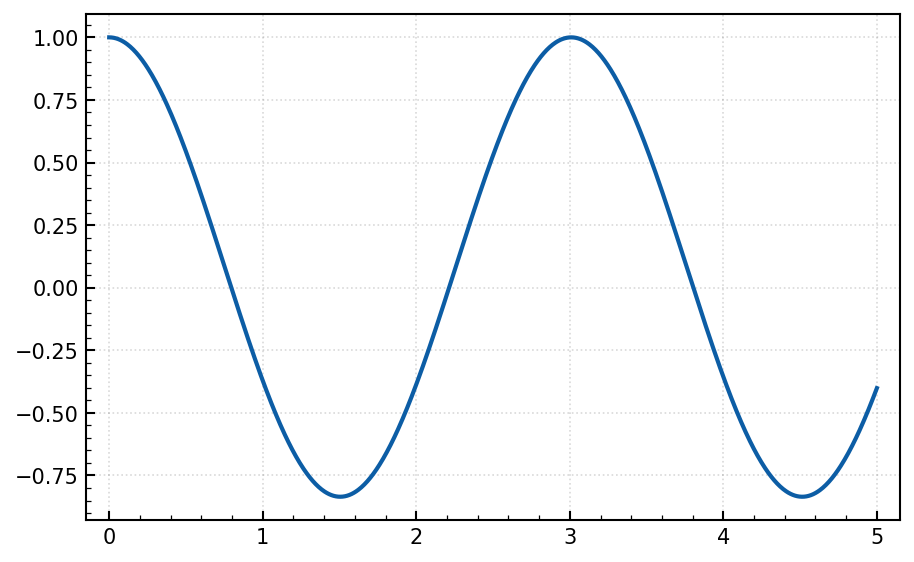

In [24]:
plt.plot(tsave, result.expects[0].real)